## Importing Packages

In [4]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [5]:
year = 2018
race = "Hungarian Grand Prix"

session = fastf1.get_session(year, race, 'R')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (780.35 MB) C:\Users\odath\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 44 completed the race distance 00:00.112000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['44', '5', '7', '3', '77', '10', '20', '14', '55', '8', '28', '2

## Load and Prepare Lap Data

In [6]:
laps = session.laps

laps = laps[[
    'Driver', 'LapNumber', 'LapTime',
    'Compound', 'TyreLife', 'Stint', 'Team'
]].dropna()

laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,Team,LapTimeSeconds
1,GAS,2.0,0 days 00:01:25.662000,ULTRASOFT,1.0,1.0,Toro Rosso,85.662
2,GAS,3.0,0 days 00:01:25.128000,ULTRASOFT,2.0,1.0,Toro Rosso,85.128
3,GAS,4.0,0 days 00:01:24.880000,ULTRASOFT,3.0,1.0,Toro Rosso,84.880
4,GAS,5.0,0 days 00:01:24.742000,ULTRASOFT,4.0,1.0,Toro Rosso,84.742
5,GAS,6.0,0 days 00:01:32.283000,ULTRASOFT,5.0,1.0,Toro Rosso,92.283


## Driver Comparison on Same Compound

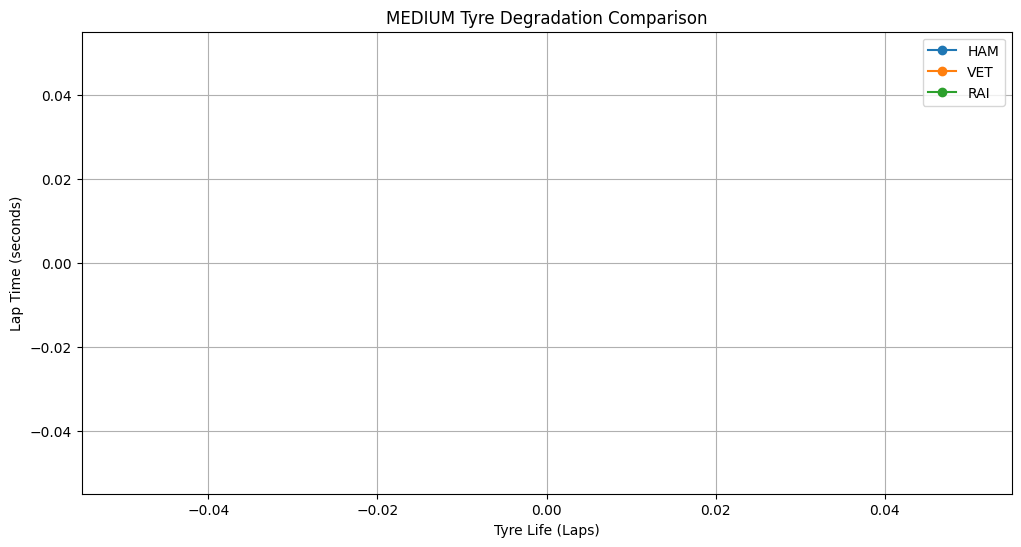

In [7]:
results = session.results

results = results.head(3)
drivers = results['Abbreviation']
compound = 'MEDIUM'

plt.figure(figsize=(12,6))

for drv in drivers:
    data = laps[
        (laps['Driver'] == drv) &
        (laps['Compound'] == compound)
    ]
    plt.plot(
        data['TyreLife'],
        data['LapTimeSeconds'],
        marker='o',
        label=drv
    )

plt.title(f"{compound} Tyre Degradation Comparison")
plt.xlabel("Tyre Life (Laps)")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()


## Driver Comparison on Different Compound

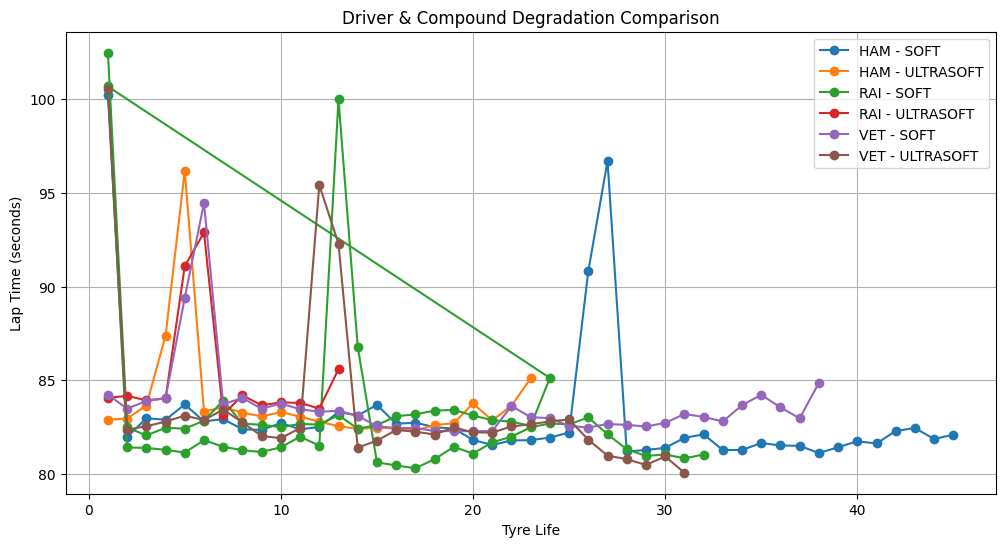

In [8]:
comparison = laps[laps['Driver'].isin(drivers)]

plt.figure(figsize=(12,6))

for (drv, comp), data in comparison.groupby(['Driver', 'Compound']):
    plt.plot(
        data['TyreLife'],
        data['LapTimeSeconds'],
        marker='o',
        label=f"{drv} - {comp}"
    )

plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (seconds)")
plt.title("Driver & Compound Degradation Comparison")
plt.legend()
plt.grid(True)
plt.show()
